In [1]:
import torch
print("Torch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)

Torch version: 2.5.1
CUDA version: 11.8


In [2]:
torch.cuda.is_available()

True

In [ ]:
tensor_cpu= torch.ones(5000,5000,dtype= torch.float32)
print(f"Tenspr create:{tensor_cpu.device}")

tensor_gpu= tensor_cpu.to(device)
print(f"Tensor moved to:{tensor_gpu.device}")

result_gpu= tensor_gpu**2

result_cpu_to_gpu = result_gpu.to("cpu")

if device.type == 'cuda':
    # On GPU, let's do the same on CPU for comparison
    result_cpu_direct = tensor_cpu ** 2
    assert torch.equal(result_cpu_from_gpu, result_cpu_direct), "GPU and CPU results differ!"
    print("Verification successful: GPU result matches CPU result.")
else:
    # If running on CPU, result_gpu is already on CPU
    print("Running on CPU, results are direct.")

print("Program finished.")

In [1]:
##Lecture 3: Feedforward Neural network and GPU

##Logistic regression is completed to identify MNISt dataset: softmax for probablistic output was done.

##

In [4]:
import torch 
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid
from torch.utils.data.dataloader import DataLoader
from torch.utils.data import random_split
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
dataset = MNIST(root='data/', download= True, transform=ToTensor())

val_size= 10000
train_size= len(dataset) - val_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])
len(train_ds), len(val_ds)

(50000, 10000)

In [6]:
batch_size = 128
train_loader = DataLoader(train_ds, batch_size, shuffle=True, num_workers= 4, pin_memory=True)
val_loader= DataLoader(val_ds, batch_size, num_workers=4, pin_memory=True)

In [7]:
torch.cuda.is_available()

True

images.shape torch.Size([128, 1, 28, 28])


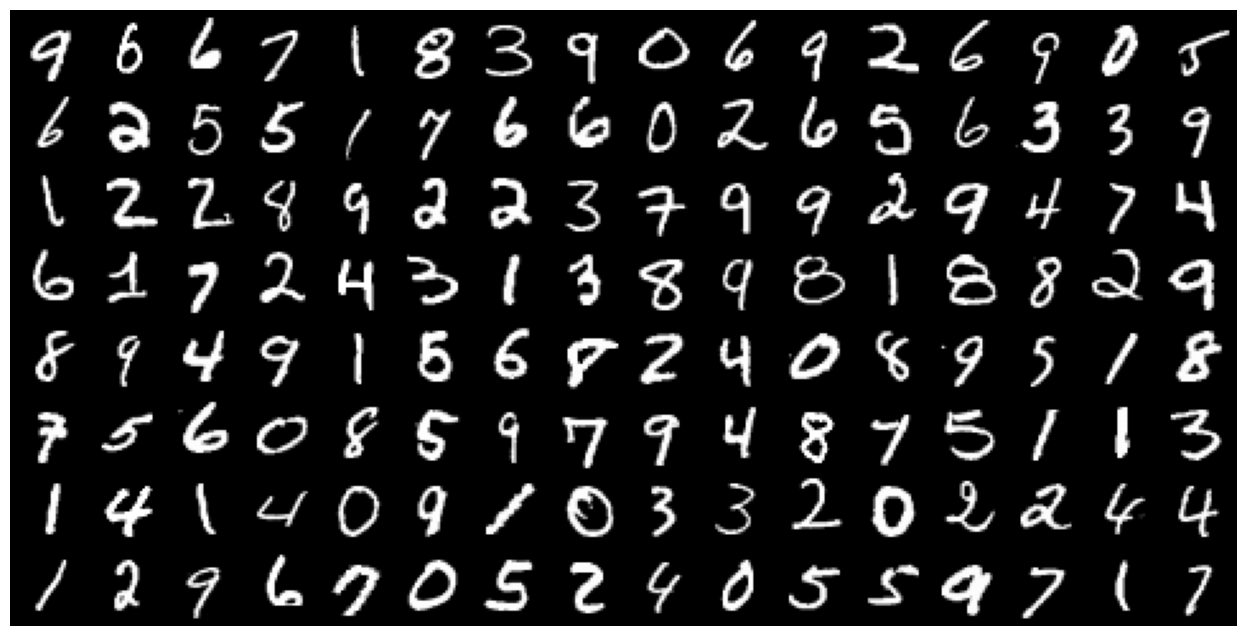

In [8]:
for images,_ in train_loader:
    print("images.shape",images.shape)
    plt.figure(figsize=(16,8))
    plt.axis("off")
    plt.imshow(make_grid(images,nrow=16).permute((1, 2, 0)))
    break

In [9]:
##The above code is to look at the data in the grid , by make_grid function

# Model
#To improve logistic regression we use one hidden layer: Feedforward NN
#def model(x):
#    retrun x*w+b #This was linear

#nn.Linear(in_size,out_size): This took 3 inputs, 2 outputs and did matrix multiplication.
#nn.Linear(in_size, out_size): Logistic: All pixels intensity was input, and output was probabiity using softmax function.

In [10]:
#Non linear activation function is used to introduce non-linearity. 

def accuracy(outputs, labels):
    _, preds= torch.max(outputs, dim =1)
    return torch.tensor(torch.sum(preds==labels).item() /len(preds))

In [36]:
class MnistModel(nn.Module):
    def __init__(self, in_size, hidden_size, out_size):
        super().__init__()
        self.linear1 = nn.Linear(in_size,hidden_size)
        self.linear2 = nn.Linear(hidden_size, out_size)

    def forward(self,xb):
        xb = xb.view(xb.size(0), -1)#Flatten the image tensor
        out= self.linear1(xb) # intermediated output
        out = F.relu(out)# nOn linear function
        out= self.linear2(out)
        return out

    def training_step(self, batch):
        images, labels= batch
        out= self(images)
        loss = F.cross_entropy(out, labels)
        return loss

    def validation_step(self, batch):
        images, labels= batch
        out= self(images)
        loss= F.cross_entropy(out, labels)
        acc= accuracy(out, labels)
        return {'val_loss': loss.detach(), 'val_acc': acc} #detaches values asscoited thus reduce memory on GPU

    def validation_epoch_end(self, outputs):
        batch_losses= [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()
        batch_acc= [x['val_acc'] for x in outputs]
        epoch_acc= torch.stack(batch_acc).mean()
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, results):
        print('Epoch [{}], val_loss:{:.4f}, val_acc:{:.4f}'.format(epoch, results['val_loss'], results['val_acc']))

    
        

In [37]:
in_size = 784
hidden_size= 32
num_classes = 10

In [38]:
model= MnistModel(in_size,hidden_size=32, out_size=num_classes)

In [39]:
for t in model.parameters():
    print(t.shape)

torch.Size([32, 784])
torch.Size([32])
torch.Size([10, 32])
torch.Size([10])


In [40]:
for images, labels in train_loader:
    outputs = model(images)
    loss= F.cross_entropy(outputs, labels)
    print('Loss', loss.item())
    break

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cpu and cuda:0! (when checking argument for argument mat1 in method wrapper_CUDA_addmm)

In [41]:
torch.cuda.is_available()

True

In [42]:
def get_default_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

device = get_default_device()
device

device(type='cuda')

In [43]:
def to_device(data, device):
    if isinstance(data, (list, tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking= True)



In [44]:
for images, labels in train_loader:
    print(images.shape)
    images= to_device(images, device)
    print(images.device)
    print(images)
    break

torch.Size([128, 1, 28, 28])
cuda:0
tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        ...,


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          

In [45]:
#DeviceDataloadr class wrap exisitinf data and move to the device

class DeviceDataLoader():
    def __init__(self, dl, device):
        self.dl= dl
        self.device= device

    def __iter__(self): # it will retrun an iterater usinf 'yield' 
        for b in self.dl:
            yield to_device(b, self.device) #yields produces sequences over time

    def __len__(self):
        return len(self.dl)

In [46]:
train_loader= DeviceDataLoader(train_loader, device)
val_loader = DeviceDataLoader(val_loader, device)


In [47]:
for xb, yb in val_loader:
    print('xb.device', xb.device)
    print('yb', yb)
    break

xb.device cuda:0
yb tensor([5, 1, 4, 8, 0, 8, 1, 9, 2, 1, 5, 0, 7, 2, 6, 7, 5, 4, 3, 9, 1, 5, 1, 6,
        4, 9, 4, 1, 7, 5, 9, 6, 4, 2, 4, 8, 8, 3, 9, 3, 0, 6, 3, 7, 1, 6, 8, 0,
        6, 1, 7, 6, 5, 3, 7, 6, 5, 6, 3, 7, 1, 9, 3, 5, 7, 1, 8, 8, 2, 5, 3, 1,
        9, 0, 7, 4, 5, 1, 7, 7, 9, 0, 6, 8, 9, 6, 2, 5, 5, 3, 4, 3, 9, 8, 9, 5,
        9, 7, 0, 8, 4, 8, 2, 9, 8, 9, 8, 2, 9, 2, 7, 9, 3, 3, 1, 0, 8, 5, 2, 6,
        4, 0, 3, 9, 2, 7, 7, 8], device='cuda:0')


In [48]:
#Training the model

def evaluate(model, val_loader):
    outputs= [model.validation_step(batch) for batch in val_loader] #validation step calculates loss 
    return model.validation_epoch_end(outputs)

def fit(epochs, lr, model, train_loader, val_loader, opt_func = torch.optim.SGD):
    history=[]
    optimizer= opt_func(model.parameters(), lr)
    for epoch in range(epochs):
        for batch in train_loader:
            loss = model.training_step(batch)
            loss.backward() #graident of the loss with respect to weight, Inp of 2nd layer= output of first layer, so goes back and calculates gradient of first layer therefore backpropagation. 
            optimizer.step()
            optimizer.zero_grad()

        results = evaluate(model, val_loader)
        model.epoch_end(epoch, results)
        history.append(results)
    return history

In [49]:
#Define accuracy function that callculates overall accuracy of the model. 

model = MnistModel(in_size, hidden_size=hidden_size, out_size=num_classes)
to_device(model, device)

MnistModel(
  (linear1): Linear(in_features=784, out_features=32, bias=True)
  (linear2): Linear(in_features=32, out_features=10, bias=True)
)

In [50]:
history = [evaluate(model, val_loader)]
history

[{'val_loss': 2.3118135929107666, 'val_acc': 0.09028876572847366}]

In [51]:
history += fit(5,0.5, model, train_loader, val_loader)

Epoch [0], val_loss:0.2252, val_acc:0.9333
Epoch [1], val_loss:0.1688, val_acc:0.9503
Epoch [2], val_loss:0.1931, val_acc:0.9444
Epoch [3], val_loss:0.1423, val_acc:0.9590
Epoch [4], val_loss:0.1741, val_acc:0.9457


Text(0.5, 1.0, 'loss vs number of epoch')

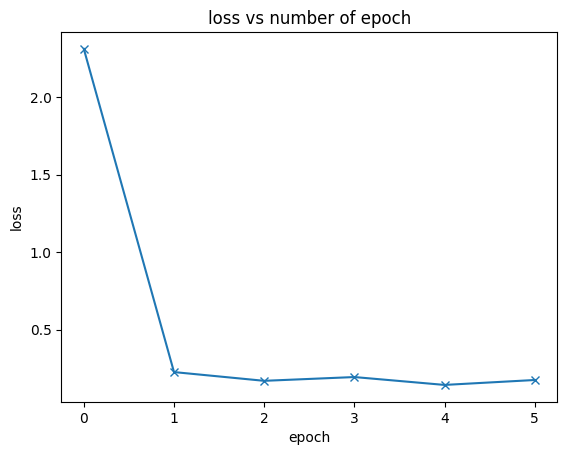

In [52]:
#96% accuracy is obatined thus try reducing the learning rate and see 

import matplotlib.pyplot as plt
%matplotlib inline

losses =[x ['val_loss'] for x in history]
plt.plot(losses,'-x')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('loss vs number of epoch')

Text(0.5, 1.0, 'accuracies vs number of epoch')

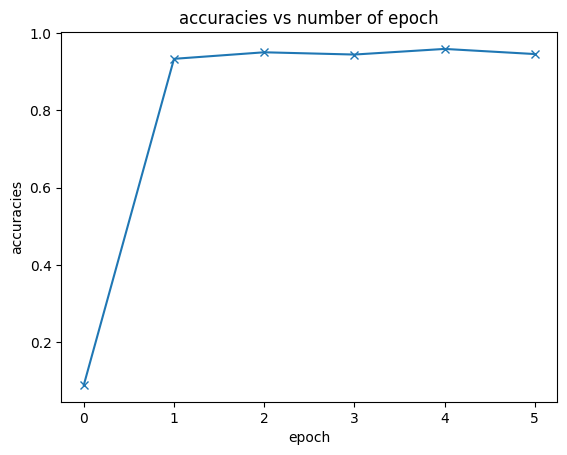

In [53]:
accuracies =[x ['val_acc'] for x in history]
plt.plot(accuracies,'-x')
plt.xlabel('epoch')
plt.ylabel('accuracies')
plt.title('accuracies vs number of epoch')

In [54]:
#this method outperforms logistic regression and reaches accuracy of 90% and then stops, to make 100% increase hidden layers.

In [ ]:
#Sigmoid function: takes output and restricts to 0 to 1, RelU takes down negatice output and only retains positive input.
#Tanh : -1 to 1 range of output

#Feedforward : takes input hidden and then output so feeding it forward.

#nn. Lineat = linear layer but sometimes data might not be central, therfore they dont have spatial invariance thus CNN comes into picture. 